Code demonstration for project viva

In [ ]:
from cppsolver.helper_functions import load_graph, edge_sum, to_odd_subproblem
from cppsolver.aco import ACO
from cppsolver.pso import PSO
from cppsolver.sa import simulated_annealing
from cppsolver.jso import JSO
from cppsolver.hybrids import ACO_SA, ACO_SA2
from cppsolver.solution_validator import solution_check
import numpy as np
import random

PART 1: Loading graphs and creating G'

In [2]:
#Graph generation is configurable with number of nodes, number of odd valency nodes and maximum edge weight.
filename = "../graphs/graph24.txt"
graph, N_nodes, N_odds, edge_count, W_max = load_graph(filename)
print("Graph loaded from", filename, "with", N_nodes, "total nodes,", N_odds, "odd nodes,", edge_count, "edges and", W_max, "maximum weight.\n")
for row in graph:
    print(" ".join(f"{x:4}" for x in row))

#example graph printed below

Graph loaded from ../graphs/graph24.txt with 24 total nodes, 16 odd nodes, 78 edges and 1000 maximum weight.

   0  830    0    0    0    0  496   50  247   60    0    0    0    0    0    0    0    0    0  213    0    0    0    0
 830    0    0    0    0  235  789    0  409    0    0    0    0    0    0  759    0    0    0    0    0    0    0  549
   0    0    0    0    0  889    0    0  113    0    0    7    0    0    0    0    0   95    0    0    0  407    0  647
   0    0    0    0   18  996    0  622  572    0    0  866    0  384    0    0    0    0  402    0    0    0    0    0
   0    0    0   18    0  960    0  170    0  647  353    0    0    0  195    0  147    0    0    0  291  602  817    0
   0  235  889  996  960    0    0    0    0    0  108    0  366    0    0    0    0  871  169    0  630    0    0    0
 496  789    0    0    0    0    0    0    0  896    0  871  288    0    0  915    0    0  376    0  113    0  926    0
  50    0    0  622  170    0    0    0    0    0 

In [3]:
#we simplify the problem by finding the minimum distance between all odd nodes using dijkstra's algorithm

#here is that subgraph for the above

odd_subgraph, odd_indexes, subgraph_of_paths = to_odd_subproblem(graph)

for row in odd_subgraph:
    print(" ".join(f"{x:4}" for x in row))

   0  479  422  188  485  298  543  396  213  839  165  451  309  426  195  421
 479    0  545  631  405  676  285  366  549  975  608  440  630  540  638  158
 422  545    0  546  512  556  435  288  471  718  551  647  113  812  581  562
 188  631  546    0  297  110  417  538  355  651  317  263  461  578  347  544
 485  405  512  297    0  307  120  253  436  848  580  460  399  520  550  247
 298  676  556  110  307    0  391  428  245  541  273  273  571  534  243  518
 543  285  435  417  120  391    0  147  330  932  664  580  519  414  634  127
 396  366  288  538  253  428  147    0  183  969  525  676  401  547  555  274
 213  549  471  355  436  245  330  183    0  786  342  518  486  603  372  457
 839  975  718  651  848  541  932  969  786    0  814  814  605 1075  784  817
 165  608  551  317  580  273  664  525  342  814    0  546  438  261   30  550
 451  440  647  263  460  273  580  676  518  814  546    0  724  666  516  598
 309  630  113  461  399  571  519  401 

PART 2: Metaheuristic optimisation

In [4]:
#Ant Colony Optimisation
solution, total = ACO(
            graph=graph,
            n_ants=10,
            N=500,
            evap_rate=0.25,
            reinforce_amount=1,
            alpha=1,
            beta=4.5
            )
print(f"ACO final tour: {solution}")
print(f"Cost: {total}")
solution_check(graph=graph, solution=solution, total=total)

ACO final tour: [0, 1, 5, 2, 8, 0, 6, 1, 8, 2, 11, 2, 17, 5, 3, 4, 3, 7, 0, 7, 4, 5, 10, 4, 9, 0, 19, 18, 3, 8, 14, 4, 16, 4, 20, 5, 10, 22, 4, 21, 2, 23, 1, 15, 6, 9, 11, 3, 13, 12, 5, 18, 6, 11, 17, 12, 6, 20, 6, 22, 9, 14, 7, 16, 14, 13, 12, 21, 11, 23, 8, 20, 15, 9, 15, 23, 10, 23, 19, 21, 16, 21, 17, 14, 13, 18, 21, 23, 22, 16, 22, 19, 0]
Cost: 39169
Congratulations. You have produced a valid tour of length 39169


In [5]:
#Particle Swarm Optimiser
solution, total = PSO(
            graph=graph,
            n_particles=50,
            iterations=100,
            alpha=0.27,
            beta=0.82,
            p_mutate=0.52
            )
print(f"PSO final tour: {solution}")
print(f"Cost: {total}")
solution_check(graph=graph, solution=solution, total=total)

PSO final tour: [0, 1, 5, 2, 8, 0, 6, 1, 8, 2, 11, 2, 17, 5, 3, 4, 3, 7, 0, 7, 4, 5, 10, 4, 9, 0, 19, 18, 3, 8, 14, 4, 16, 4, 20, 5, 10, 22, 4, 21, 2, 23, 1, 15, 6, 9, 11, 3, 13, 12, 5, 18, 6, 11, 17, 12, 6, 12, 21, 11, 23, 8, 20, 6, 22, 9, 14, 7, 16, 14, 9, 15, 20, 15, 23, 10, 23, 19, 21, 16, 21, 17, 14, 13, 18, 21, 23, 22, 16, 22, 19, 0]
Cost: 39470
Congratulations. You have produced a valid tour of length 39470


In [6]:
#Jellyfish Search Optimiser
solution, total = JSO(
            graph=graph,
            nJellyfish=10,
            MaxIt=500,
            beta=3,
            gamma=0.1
        )
print(f"JSO final tour: {solution}")
print(f"Cost: {total}")
solution_check(graph=graph, solution=solution, total=total)

JSO final tour: [0, 1, 5, 2, 8, 0, 6, 1, 8, 0, 7, 0, 9, 0, 19, 18, 3, 4, 3, 5, 4, 7, 3, 8, 14, 4, 9, 6, 11, 2, 11, 3, 13, 12, 5, 10, 4, 16, 4, 20, 5, 10, 22, 4, 21, 2, 17, 2, 23, 1, 15, 6, 12, 17, 5, 18, 6, 20, 6, 22, 9, 11, 17, 12, 21, 11, 23, 8, 20, 15, 9, 14, 7, 16, 14, 9, 15, 23, 10, 23, 19, 21, 16, 21, 17, 14, 13, 18, 21, 23, 22, 16, 22, 19, 0]
Cost: 39565
Congratulations. You have produced a valid tour of length 39565


In [7]:
#Simulated Annealing
solution, total = simulated_annealing(
            graph=graph,
            start_temp=1000,
            iterations=5000,
            cooling_rate=0.995,
        )
print(f"SA final tour: {solution}")
print(f"Cost: {total}")
solution_check(graph=graph, solution=solution, total=total)

SA final tour: [0, 1, 5, 2, 8, 0, 6, 1, 8, 2, 11, 2, 17, 5, 3, 4, 3, 7, 0, 7, 4, 5, 10, 4, 9, 0, 19, 18, 3, 8, 14, 4, 16, 4, 20, 5, 10, 22, 4, 21, 2, 23, 1, 15, 6, 9, 11, 3, 13, 12, 5, 18, 6, 11, 17, 12, 6, 12, 21, 11, 23, 8, 20, 6, 22, 9, 14, 7, 16, 14, 9, 15, 20, 15, 23, 10, 23, 19, 21, 16, 21, 17, 14, 13, 18, 21, 23, 22, 16, 22, 19, 0]
Cost: 39470
Congratulations. You have produced a valid tour of length 39470


In [8]:
#ACO-SA (local)
solution, total = ACO_SA(
            graph=graph,
            n_ants=10,
            ACO_it=450,
            evap_rate=0.01,
            reinforce_amount=1,
            alpha=1.9,
            beta=5,
            start_temp=1000,
            SA_it=28,
            cooling_rate=0.96,
            interval=25
            )
print(f"ACO-SA final tour: {solution}")
print(f"Cost: {total}")
solution_check(graph=graph, solution=solution, total=total)

ACO-SA final tour: [0, 1, 5, 2, 8, 0, 6, 1, 8, 2, 11, 2, 17, 5, 3, 4, 3, 7, 0, 7, 4, 5, 10, 4, 9, 0, 19, 18, 3, 8, 14, 4, 16, 4, 20, 5, 10, 22, 4, 21, 2, 23, 1, 15, 6, 9, 11, 3, 13, 12, 5, 18, 6, 11, 17, 12, 6, 20, 6, 22, 9, 14, 7, 16, 14, 13, 12, 21, 11, 23, 8, 20, 15, 9, 15, 23, 10, 23, 19, 21, 16, 21, 17, 14, 13, 18, 21, 23, 22, 16, 22, 19, 0]
Cost: 39169
Congratulations. You have produced a valid tour of length 39169


In [9]:
#ACO-SA2 (global)
solution, total = ACO_SA2(
            graph=graph,
            n_ants=10,
            ACO_it=450,
            evap_rate=0.07,
            reinforce_amount=1,
            alpha=1.4,
            beta=3.4,
            start_temp=1000,
            SA_it=500,
            cooling_rate=0.995
            )
print(f"ACO-SA final tour: {solution}")
print(f"Cost: {total}")
solution_check(graph=graph, solution=solution, total=total)

ACO-SA final tour: [0, 1, 5, 2, 8, 0, 6, 1, 8, 2, 11, 2, 17, 5, 3, 4, 3, 7, 0, 7, 4, 5, 10, 4, 9, 0, 19, 18, 3, 8, 14, 4, 16, 4, 20, 5, 10, 22, 4, 21, 2, 23, 1, 15, 6, 9, 11, 3, 13, 12, 5, 18, 6, 11, 17, 12, 6, 20, 6, 22, 9, 14, 7, 16, 14, 13, 12, 21, 11, 23, 8, 20, 15, 9, 15, 23, 10, 23, 19, 21, 16, 21, 17, 14, 13, 18, 21, 23, 22, 16, 22, 19, 0]
Cost: 39169
Congratulations. You have produced a valid tour of length 39169


PART 3: Main experiment

In [ ]:
#in non-hybrid algorithms: budget = iterations * actors
n_trials = 3

budget = 5000
ant_actors = 10
jellyfish_actors = 10
particle_actors = 50
population_actors = 100

interval = 25 #interval at which SA is performed in ACO_SA
aco_sa_local_prop = 0.9 #proportion of budget to go to ACO in ACO_SA
aco_sa_global_prop = 0.9 #proportion of budget to go to ACO in ACO_SA2

ACO_it_hybrid_local = int(aco_sa_local_prop*budget)//ant_actors
SA_it_hybrid_local = (budget - ACO_it_hybrid_local*ant_actors)//(ACO_it_hybrid_local//interval)
ACO_it_hybrid_global = int(aco_sa_global_prop*budget)//ant_actors
SA_it_hybrid_global = budget - ACO_it_hybrid_global*ant_actors

score_only = True
time_limit = float("inf")
stag_limit = float("inf")

table = []
graphs = ["graph4", "graph10", "graph24", "graph100", "graph200"] #any new graphs generated by the generator can be added here
algs = ["ACO", "PSO", "JSO", "SA", "ACO-SA", "ACO-SA2"]
table.append([f"{n_trials}-run best/"]+algs)
table.append(["mean/std", "", "", "", "", "", ""])
n_graphs = len(graphs)
results = []

for g in range(n_graphs):
    print(f"Preparing {graphs[g]}...")
    filename = "../graphs/" + graphs[g] + ".txt"
    graph, N_nodes, N_odds, edge_count, W_max = load_graph(filename)

    #Precomputed for each graph
    odd_info = to_odd_subproblem(graph)
    edge_total = edge_sum(graph)
    
    print(f"    {graphs[g]} odd_info and edge_total have been precomputed. Beginning experiments...")

    ACO_trials = []
    PSO_trials = []
    SA_trials = []
    ACO_SA_trials = []
    ACO_SA2_trials = []
    JSO_trials = []

    for i in range(n_trials):
        random.seed(i)
        _, total = ACO(
            graph=graph,
            odd_info=odd_info,
            score_only=score_only,
            edge_total=edge_total,
            n_ants=ant_actors,
            N=budget//ant_actors,
            evap_rate=0.25,
            reinforce_amount=1,
            alpha=1,
            beta=4.5,
            time_limit=time_limit,
            stag_limit=stag_limit
            )
        ACO_trials.append(total)
        if g >= 3: #to see progress on large graphs
            print("     ACO done.")
            
        _, total = PSO(
            graph=graph,
            odd_info=odd_info,
            score_only=score_only,
            edge_total=edge_total,
            n_particles=particle_actors,
            iterations=budget//particle_actors,
            alpha=0.27,
            beta=0.82,
            p_mutate=0.52,
            time_limit=time_limit,
            stag_limit=stag_limit
            )
        PSO_trials.append(total)
        if g >= 3:
            print("     PSO done.")
        
        _, total = JSO(
            graph=graph,
            odd_info=odd_info,
            score_only=score_only,
            edge_total=edge_total,
            nJellyfish=jellyfish_actors,
            MaxIt=budget//jellyfish_actors,
            beta=3,
            gamma=0.1,
            time_limit=time_limit,
            stag_limit=stag_limit
        )
        JSO_trials.append(total)
        if g >= 3:
            print("     JSO done.")

        _, total = simulated_annealing(
            graph=graph,
            odd_info=odd_info,
            score_only=score_only,
            edge_total=edge_total,
            start_temp=1000,
            iterations=budget,
            cooling_rate=0.995,
            time_limit=time_limit,
            stag_limit=stag_limit
        )
        SA_trials.append(total)
        if g >= 3:
            print("     SA done.")

        _, total = ACO_SA(
            graph=graph,
            odd_info=odd_info,
            score_only=score_only,
            edge_total=edge_total,
            n_ants=ant_actors,
            ACO_it=ACO_it_hybrid_local,
            evap_rate=0.01,
            reinforce_amount=1,
            alpha=1.9,
            beta=5,
            start_temp=1000,
            SA_it=SA_it_hybrid_local,
            cooling_rate=0.96,
            interval=interval,
            time_limit=time_limit,
            stag_limit=stag_limit
            )
        ACO_SA_trials.append(total)
        if g >= 3:
            print("     ACO-SA done.")

        _, total = ACO_SA2(
            graph=graph,
            odd_info=odd_info,
            score_only=score_only,
            edge_total=edge_total,
            n_ants=ant_actors,
            ACO_it=ACO_it_hybrid_global,
            evap_rate=0.07,
            reinforce_amount=1,
            alpha=1.4,
            beta=3.4,
            start_temp=1000,
            SA_it=SA_it_hybrid_global,
            cooling_rate=0.995,
            time_limit=time_limit,
            stag_limit=stag_limit
            )
        ACO_SA2_trials.append(total)
        if g >= 3:
            print("     ACO-SA2 done.")

        print(f"    {graphs[g]} trial {i+1} successfully completed for all algorithms.")
    
    ACO_trials = np.array(ACO_trials)
    PSO_trials = np.array(PSO_trials)
    SA_trials = np.array(SA_trials)
    ACO_SA_trials = np.array(ACO_SA_trials)
    ACO_SA2_trials = np.array(ACO_SA2_trials)
    JSO_trials = np.array(JSO_trials)

    graph_results = [ACO_trials, PSO_trials, SA_trials, ACO_SA_trials, ACO_SA2_trials, JSO_trials]
    results.append(graph_results)

    ACO_av = np.mean(ACO_trials)
    PSO_av = np.mean(PSO_trials)
    SA_av = np.mean(SA_trials)
    ACO_SA_av = np.mean(ACO_SA_trials)
    ACO_SA2_av = np.mean(ACO_SA2_trials)
    JSO_av = np.mean(JSO_trials)

    ACO_std = np.std(ACO_trials)
    PSO_std = np.std(PSO_trials)
    SA_std = np.std(SA_trials)
    ACO_SA_std = np.std(ACO_SA_trials)
    ACO_SA2_std = np.std(ACO_SA2_trials)
    JSO_std = np.std(JSO_trials)
    
    ACO_best = np.min(ACO_trials)
    PSO_best = np.min(PSO_trials)
    SA_best = np.min(SA_trials)
    ACO_SA_best = np.min(ACO_SA_trials)
    ACO_SA2_best = np.min(ACO_SA2_trials)
    JSO_best = np.min(JSO_trials)

    bests = [f"{graphs[g]}",
             f"{ACO_best}/",
             f"{PSO_best}/",
             f"{JSO_best}/",
             f"{SA_best}/",
             f"{ACO_SA_best}/",
             f"{ACO_SA2_best}/"]
    row = ["",
            f"{ACO_av:.1f}/{ACO_std:.2f}",
            f"{PSO_av:.1f}/{PSO_std:.2f}",
            f"{JSO_av:.1f}/{JSO_std:.2f}",
            f"{SA_av:.1f}/{SA_std:.2f}",
            f"{ACO_SA_av:.1f}/{ACO_SA_std:.2f}",
            f"{ACO_SA2_av:.1f}/{ACO_SA2_std:.2f}"]

    print(f"    {graphs[g]} experiments are complete.")
    table.append(bests)
    table.append(row)
    table.append([])

print("\n")
for row in table:
    print(" ".join(f"{x:16}" for x in row))

#hyperparameters are tuned to 2sf where appropriate via Bayseian Optimisation with a 20 round optuna study
#the study minimises the 5-run average on graph 100

Preparing graph4...
    graph4 odd_info and edge_total have been precomputed. Beginning experiments...
    graph4 trial 1 successfully completed for all algorithms.
    graph4 trial 2 successfully completed for all algorithms.
    graph4 trial 3 successfully completed for all algorithms.
    graph4 experiments are complete.
Preparing graph10...
    graph10 odd_info and edge_total have been precomputed. Beginning experiments...
    graph10 trial 1 successfully completed for all algorithms.
    graph10 trial 2 successfully completed for all algorithms.
    graph10 trial 3 successfully completed for all algorithms.
    graph10 experiments are complete.
Preparing graph24...
    graph24 odd_info and edge_total have been precomputed. Beginning experiments...
    graph24 trial 1 successfully completed for all algorithms.
    graph24 trial 2 successfully completed for all algorithms.
    graph24 trial 3 successfully completed for all algorithms.
    graph24 experiments are complete.
Preparing 

PART 4: Boxplots and convergence

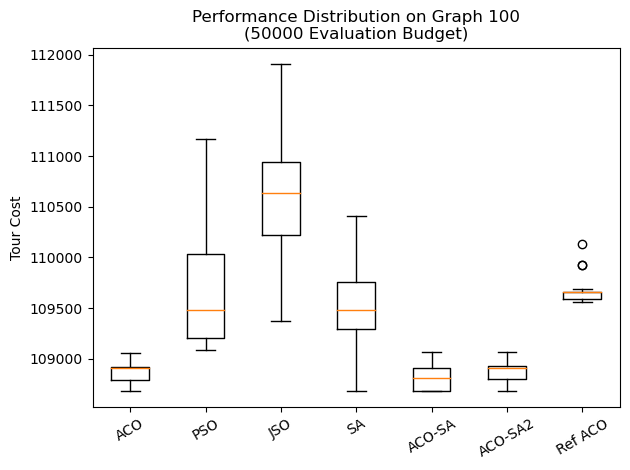

In [11]:
import matplotlib.pyplot as plt

#an example set of results saved manually from the above experiment with budget = 50000, n_trials = 20

results = [[
    [3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513],
    [3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513],
    [3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513],
    [3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513],
    [3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513],
    [3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513],
    [3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513, 3513]],
    [
    [790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790],
    [790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790],
    [790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790],
    [790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790],
    [790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790],
    [790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790],
    [790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790, 790]],
    [
    [39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39289, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169],
    [39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169],
    [39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169],
    [39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169],
    [39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169],
    [39289, 39169, 39169, 39289, 39169, 39169, 39289, 39289, 39169, 39169, 39289, 39169, 39289, 39169, 39289, 39289, 39169, 39169, 39289, 39169],
    [39169, 39169, 39169, 39169, 39289, 39169, 39289, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39169, 39289, 39169, 39320, 39169]],
    [
    [108907, 108687, 108687, 108845, 108919, 108687, 109059, 108881, 108783, 108796, 108943, 108907, 109015, 108943, 108907, 108907, 108907, 108687, 108927, 108907],
    [110028, 109136, 109208, 109557, 109520, 110051, 109136, 109439, 109263, 109407, 110619, 110721, 109085, 109354, 110066, 109154, 110033, 109208, 109530, 111167],
    [110089, 109085, 109319, 109811, 109417, 109825, 109397, 109307, 109749, 108687, 109802, 109578, 109644, 109260, 110405, 108687, 109737, 109417, 108687, 109537],
    [108687, 109065, 108845, 108907, 108687, 108687, 108819, 108919, 108796, 108907, 108687, 108687, 109065, 108687, 108881, 108907, 108783, 108907, 108687, 108687],
    [109065, 108907, 108919, 108907, 108687, 108919, 108687, 108907, 108907, 108687, 108845, 109065, 108919, 108845, 109065, 108943, 108687, 108687, 108881, 109065],
    [109927, 109927, 109691, 109655, 109655, 109595, 109559, 109655, 109595, 109595, 109655, 109559, 109655, 109595, 109655, 109655, 109691, 110129, 109655, 109559],
    [110720, 110224, 111078, 109770, 110208, 110456, 110920, 111908, 111671, 110860, 110996, 110627, 109523, 111164, 110642, 109373, 110101, 110694, 110366, 110353]],
    [
    [317804, 318091, 317774, 318066, 317670, 317897, 318067, 318013, 318074, 317938, 318045, 317961, 317774, 317931, 317890, 317822, 318153, 317984, 318089, 317747],
    [320451, 319486, 319903, 319672, 318635, 320463, 319430, 319463, 320078, 318868, 319372, 319617, 319454, 319931, 318803, 319047, 320218, 318747, 318966, 318824],
    [318340, 318680, 319219, 318967, 318057, 318188, 318359, 319816, 318687, 317992, 318041, 318672, 319214, 319173, 318162, 318383, 318729, 319646, 318655, 318414],
    [317631, 317594, 317640, 317648, 317486, 317631, 317643, 317644, 317648, 317604, 317689, 317668, 317668, 317618, 317648, 317452, 317582, 317648, 317652, 317656],
    [317623, 317643, 317474, 317643, 317636, 317623, 317623, 317636, 317449, 317631, 317644, 317623, 317631, 317584, 317759, 317615, 317648, 317656, 317644, 317631],
    [319258, 319309, 319113, 319076, 319115, 319222, 319258, 319222, 319235, 319282, 319242, 319243, 319282, 319113, 319092, 319092, 319282, 319282, 319282, 319076],
    [324737, 326895, 327130, 326639, 327751, 329299, 325917, 327989, 326479, 327192, 327492, 325892, 327493, 329431, 326843, 327813, 325241, 325381, 326644, 329139]]]

#ACO_trials, PSO_trials, SA_trials, ACO_SA_trials, ACO_SA2_trials, s_ACO_trials, JSO_trials

#results[graph_code][x]
#ACO: x = 0
#PSO: x = 1
#SA: x = 2
#ACO-SA: x = 3
#ACO-SA2: x = 4
#Ref ACO: x = 5
#JSO: x = 6

graph_names = ["4", "10", "24", "100", "200"]

graph_code = 3

data = [
    results[graph_code][0],
    results[graph_code][1],
    results[graph_code][6],
    results[graph_code][2],
    results[graph_code][3],
    results[graph_code][4],
    results[graph_code][5],
]

labels = ["ACO", "PSO", "JSO", "SA", "ACO-SA", "ACO-SA2", "Ref ACO"]

plt.figure()
plt.boxplot(data, labels=labels)
plt.ylabel("Tour Cost")
plt.title(f"Performance Distribution on Graph {graph_names[graph_code]}\n(50000 Evaluation Budget)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#Please note that the code for "Ref ACO" has been removed from this repository as it belongs to a third party:
#G. A. Sgarro and L. Grilli, “Ant colony optimization for
#Chinese postman problem,” Neural Computing and Applications,
#vol. 36, no. 6, pp. 2901–2920, 11 2023. [Online]. Available:
#https://doi.org/10.1007/s00521-023-09195-4

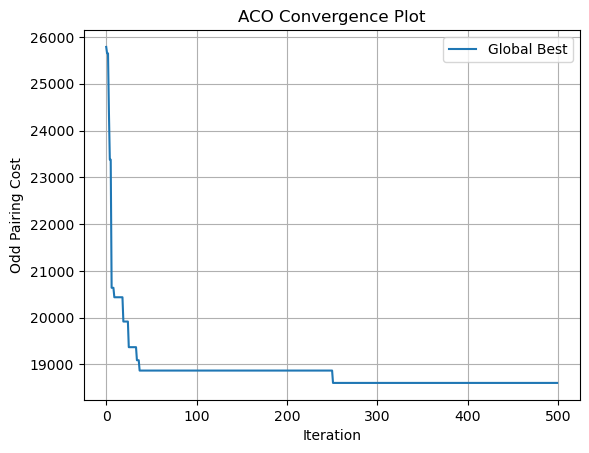

In [12]:
#ACO convergence plot on graph200
filename = "../graphs/graph200.txt"
graph, N_nodes, N_odds, edge_count, W_max = load_graph(filename)
random.seed(0)
budget = 5000
ant_actors = 10
_, total = ACO(
    graph=graph,
    score_only=True,
    n_ants=ant_actors,
    N=budget//ant_actors,
    evap_rate=0.25,
    reinforce_amount=1,
    alpha=1,
    beta=4.5,
    time_limit=float("inf"),
    stag_limit=float("inf"),
    make_plot=True
    )